In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.pyplot import figure
from astropy.io import fits

from astropy import units as u
from astropy.table import QTable

from matplotlib import rcParams

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 12,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

# Comparison with open cluster members

In this notebook, we find open cluster member stars in the test set, and compare their "Lux" predicted abundances with their measured values from the [Open Cluster Chemical Abundance and Mapping catalog](https://www.sdss.org/dr19/data_access/value-added-catalogs?vac_id=10017).

In [2]:
def Table_to_pandas(fn, slice=2):
    data = fits.open(fn)
    df = QTable(data[slice].data)
    cols = []
    cols_drop = []
    for i in df.columns:
        if np.size(df[i][0])==1:
            cols.append(i)
        else:
            cols_drop.append(i)
    print(cols_drop)
    return df[cols].to_pandas()

In [3]:
lux_output_dwarfs = pd.read_csv("data/dwarfs_predicted_with_alpha_m.csv")
lux_output_giants = pd.read_csv("data/giants_predicted_with_alpha_m.csv")
lux_output = pd.concat([lux_output_dwarfs, lux_output_giants])
lux_output.head()

,teff,logg,fe_h,mg_h,n_h,si_h,ni_h,ca_h,m_h_atm,alpha_m_atm,source_id,ce_h
0,6653.781686,4.401532,0.029955,-0.070445,0.572306,0.090616,-0.021605,0.121524,0.030913,-0.002258,514005609922766336,NaN
1,5895.453451,4.518027,0.015007,-0.010464,-0.080197,-0.065863,-0.079009,-0.029722,0.013022,0.002161,464474363446935808,NaN
2,6405.878682,4.095664,-0.216608,-0.179103,-0.151562,-0.162280,-0.222390,-0.136659,-0.216812,0.058739,464554696516584960,NaN
3,6174.013634,4.160862,-0.330735,-0.331563,-0.057243,-0.292748,-0.321633,-0.372887,-0.332450,0.038835,464654614636219392,NaN
4,5575.205025,4.302679,-0.437121,-0.280982,-0.322961,-0.334373,-0.380146,-0.219572,-0.434037,0.122983,464862765927212416,NaN


In [4]:
occam_df = Table_to_pandas("data/occam_member-DR19.fits", slice=1)
occam_df.head()

[]


,Cluster,SDSS_ID,GaiaDR3_ID,GaiaDR2_ID,OBJ_ID,GLON,GLAT,RAdeg,DEdeg,V_RAD,...,E_PMRA,PMDE,E_PMDE,FeH_ASPCAP,E_FeH_ASPCAP,CG_Prob,RV_Prob,FeH_Prob_ASPCAP,EH_Prob,XMatch
0,ASCC_123,65715684,2003443437181978240,2003443437181978240,2M22420018+5500585,105.031082,-3.292775,340.500892,55.016242,-4.200000,...,0.011,-1.481,0.010,-0.033,0.011,1.0,1.000,1.000,0.00,0
1,ASCC_19,75863939,3220092532644062720,3220092532644062720,2M05252064-0210309,204.766052,-20.095985,81.335947,-2.175249,23.739000,...,0.031,-1.662,0.025,0.021,0.010,0.9,0.947,0.946,0.00,0
2,ASCC_19,75865628,3220302676802812928,3220302676802812928,2M05270085-0117575,204.156662,-19.313450,81.753553,-1.299321,22.586000,...,0.018,-1.098,0.013,0.032,0.011,1.0,1.000,0.946,0.98,0
3,ASCC_21,75997225,3236296963215511168,3236296963215511168,2M05280884+0403101,199.388351,-16.460329,82.036839,4.052825,41.023998,...,0.096,-1.699,0.068,0.089,0.011,0.7,1.000,1.000,0.00,0
4,ASCC_99,83851784,4086373756778679680,4086373756778679680,2M18510518-1845424,16.074387,-8.358598,282.771629,-18.761790,-29.879000,...,0.014,-1.450,0.011,0.153,0.011,1.0,1.000,1.000,0.00,1


In [5]:
matched_stars_in_lux = lux_output[lux_output['source_id'].isin(occam_df['GaiaDR3_ID'])]
matched_stars_in_occam = occam_df[occam_df['GaiaDR3_ID'].isin(lux_output['source_id'])]

print(f"len matched in lux = {len(matched_stars_in_lux)} and len matched in occam = {len(matched_stars_in_occam)}")

len matched in lux = 22 and len matched in occam = 22


In [6]:
# Merge the two datasets so the same stars are matched perfectly in one row
merged_stars = pd.merge(
    matched_stars_in_occam, 
    matched_stars_in_lux, 
    left_on='GaiaDR3_ID', 
    right_on='source_id'
)
merged_stars.head()

,Cluster,SDSS_ID,GaiaDR3_ID,GaiaDR2_ID,OBJ_ID,GLON,GLAT,RAdeg,DEdeg,V_RAD,...,fe_h,mg_h,n_h,si_h,ni_h,ca_h,m_h_atm,alpha_m_atm,source_id,ce_h
0,COIN-Gaia_25,77058560,3375166759272755712,3375166759272755712,2M06082328+2008448,190.197464,0.058381,92.097013,20.145787,-14.483,...,0.086458,-0.090561,0.493914,-0.008739,-0.085445,0.142746,0.059500,-0.086656,3375166759272755712,0.169007
1,Melotte_111,80836202,4008706733584941312,4008706733584941312,2M12214901+2632568,216.260925,83.368065,185.454218,26.549063,0.614,...,-0.004561,-0.079633,0.055705,-0.017911,-0.069923,0.135361,-0.029419,-0.016735,4008706733584941312,NaN
2,Melotte_111,80584511,3958022924036722048,3958022924036722048,2M12521160+2522245,308.487396,88.237053,193.048345,25.373459,0.057,...,0.037078,-0.053939,0.145437,0.075912,0.055128,0.082535,0.042169,-0.037886,3958022924036722048,NaN
3,Melotte_22,115036486,65242069352190976,65242069352190976,2M03435880+2352578,166.182388,-24.157000,55.995111,23.882527,4.907,...,-0.054608,-0.156383,-0.070935,0.048623,-0.233276,-0.144664,-0.033728,-0.033176,65242069352190976,NaN
4,Melotte_22,115035542,65020414679879296,65020414679879296,2M03475252+2356286,166.860886,-23.516043,56.968954,23.941024,6.695,...,0.102156,-0.008419,0.210012,0.028693,0.094424,0.173620,0.099765,-0.062124,65020414679879296,NaN


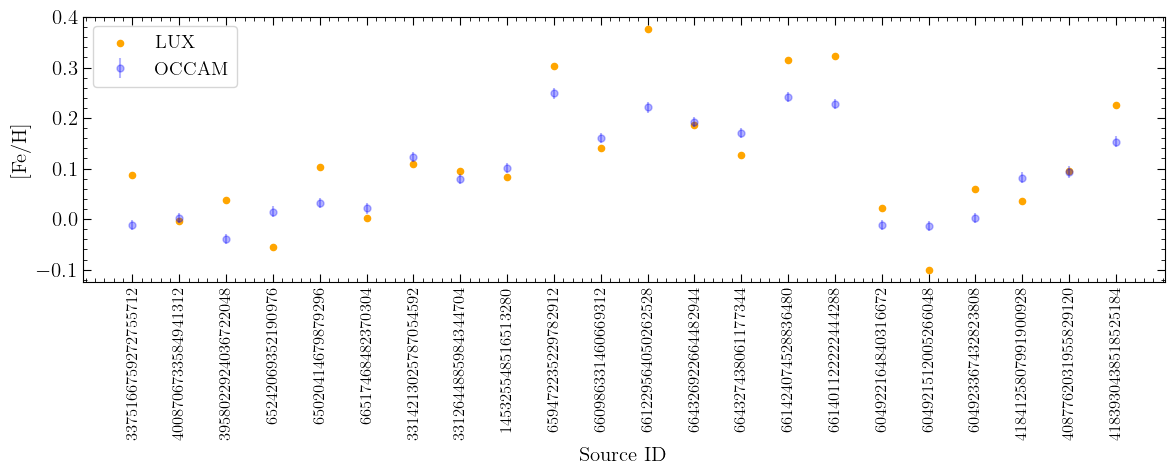

In [9]:
# Save star IDs as a string for plotting
for index, row in merged_stars.iterrows():
    string_id = str(int(row['source_id'])) 
    merged_stars.loc[index, 'string_id'] = string_id

# Plotting Lux predicted vs. OCCAM abundances for cross-matched stars
plt.figure(figsize=(12, 5))

# Plot both sets of values against the exact same string IDs
plt.errorbar(merged_stars['string_id'], merged_stars['FeH_ASPCAP'], yerr = matched_stars_in_occam['E_FeH_ASPCAP'],
             label='OCCAM', color='blue', fmt = 'o', alpha = 0.3, markersize=5)
plt.scatter(merged_stars['string_id'], merged_stars['fe_h'], label='LUX', color='orange', s=20)

plt.xlabel('Source ID')
plt.ylabel('[Fe/H]')
plt.legend(loc = 'upper left')

# Rotate the x-axis labels
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig('plots/occam_compare.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [8]:
# Error statistics between Lux predicted and OCCAM values

merged_stars['squared_err'] = (merged_stars['FeH_ASPCAP'] - merged_stars['fe_h'])**2
mse = np.mean(merged_stars['squared_err'])
print("MSE = ", mse)
rmse = np.sqrt(mse)
print("RMSE = ", rmse)

MSE =  0.004087229399023217
RMSE =  0.06393144296059035
